In [2]:
import pandas as pd

In [3]:
results2 = pd.read_csv("../data/sentiment_results/post_level_results_2.csv")
results3 = pd.read_csv("../data/sentiment_results/post_level_results_3.csv")

results2 = results2.rename(columns={ "llm_sentiment": "llm_label_second", "llm_confidence": "llm_conf_second", "llm_reasoning": "llm_reason_second" })
results3 = results3.rename(columns={ "llm_sentiment": "llm_label_third", "llm_confidence": "llm_conf_third", "llm_reasoning": "llm_reason_third"})

results = results2.merge( results3[["id", "llm_label_third", "llm_conf_third", "llm_reason_third"]], on="id", how="left")
results = results.reset_index(drop=True)

In [17]:
# Teeme topic based meelestatuse viis klassi kolmeks klassiks

# Võtame "strongly negative" ja "negative" kokku -> "negative"
# Muudame "negative or neutral" -> "neutral"
# Võtame "strongly positive" ja "positive" kokku -> "positive"
def topic_to_3(label):
    if label in ["strongly negative", "negative"]:
        return "negative"
    if label == "negative or neutral":
        return "neutral"
    if label in ["positive", "strongly positive"]:
        return "positive"
    return label

results["topic_label_3class"] = results["topic_label"].apply(topic_to_3)

In [26]:
results.columns

Index(['id', 'subreddit_name', 'source_set', 'score', 'created_utc',
       'clean_post_text', 'overall_label', 'overall_negative',
       'overall_neutral', 'overall_positive', 'topic_label',
       'topic_strongly_negative', 'topic_negative',
       'topic_negative_or_neutral', 'topic_positive',
       'topic_strongly_positive', 'llm_label_second', 'llm_conf_second',
       'llm_reason_second', 'llm_label_third', 'llm_conf_third',
       'llm_reason_third', 'topic_label_3class'],
      dtype='str')

## Mudelite klassifitseerimise jaotused

# Mudelite klassifitseerimise jaotused

In [28]:
import pandas as pd

labels = ["negative", "neutral", "positive"]

def precent_distribution(model_labels):
    counts = model_labels.value_counts(normalize=True).reindex(labels, fill_value=0)
    return (counts * 100).round(1)

table = pd.DataFrame({
    "Üldine mudel": precent_distribution(results["overall_label"]),
    "Teemapõhine mudel": precent_distribution(results["topic_label_3class"]),
    "LLM-1": precent_distribution(results["llm_label_second"]),
    "LLM-2": precent_distribution(results["llm_label_third"]),
})


table.index = ["Negatiivne", "Neutraalne", "Positiivne"]
table = table.astype(str) + "%"
table

,Üldine mudel,Teemapõhine mudel,LLM-1,LLM-2
Negatiivne,21.0%,11.8%,18.7%,26.9%
Neutraalne,66.0%,69.4%,57.8%,62.4%
Positiivne,13.0%,18.7%,23.5%,10.7%


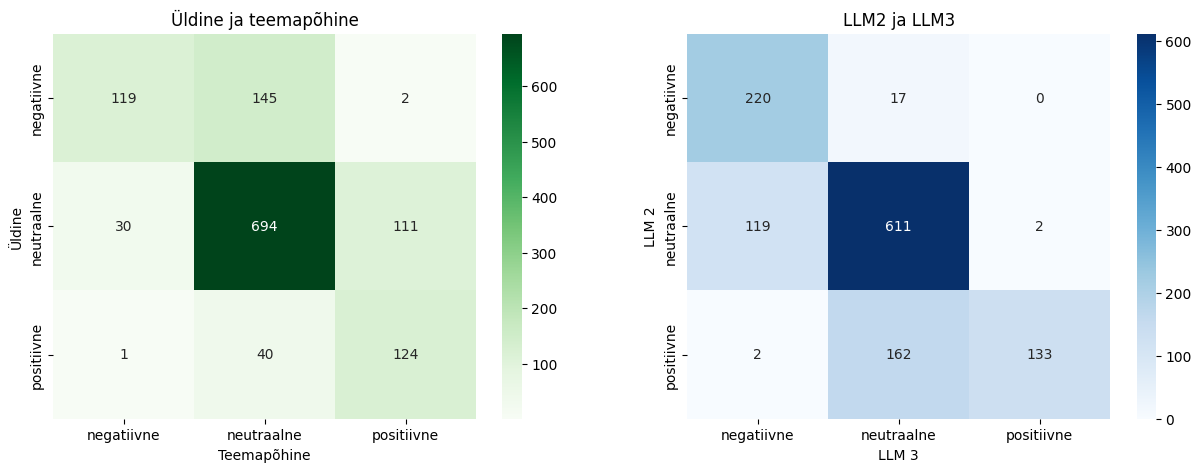

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

overall_vs_topic = pd.crosstab(results["overall_label"], results["topic_label_3class"])
llm2_vs_llm3 = pd.crosstab(results["llm_label_second"], results["llm_label_third"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine
sns.heatmap(overall_vs_topic, annot=True, fmt="d",
    cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[0])

axes[0].set_title("Üldine ja teemapõhine")
axes[0].set_xlabel("Teemapõhine")
axes[0].set_ylabel("Üldine")


# Üldine ja LLM
sns.heatmap(llm2_vs_llm3, annot=True, fmt="d",
    cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])

axes[1].set_title("LLM2 ja LLM3")
axes[1].set_xlabel("LLM 3")
axes[1].set_ylabel("LLM 2")


plt.show();


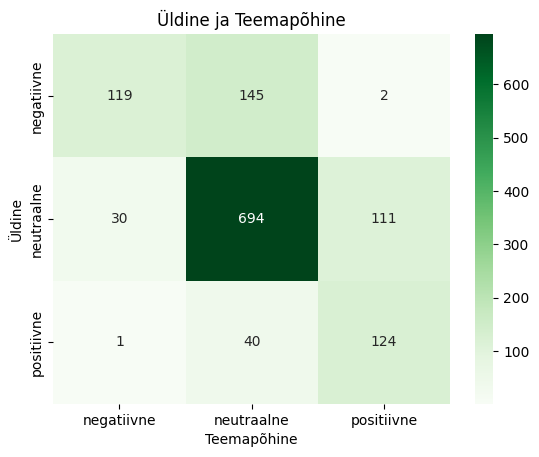

In [31]:
overall_vs_topic = pd.crosstab(results["overall_label"], results["topic_label_3class"])

labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine

#fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(overall_vs_topic, annot=True, fmt="d",
    cmap="Greens", xticklabels=labels, yticklabels=labels)

plt.title("Üldine ja Teemapõhine")
plt.xlabel("Teemapõhine")
plt.ylabel("Üldine")


plt.show();


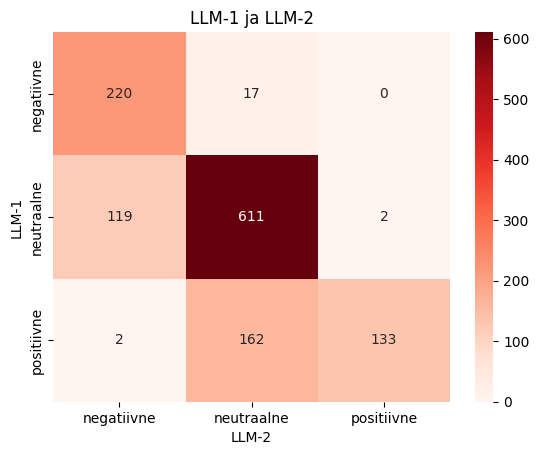

In [35]:
llm2_vs_llm3 = pd.crosstab(results["llm_label_second"], results["llm_label_third"])

labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine

#fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(llm2_vs_llm3, annot=True, fmt="d",
    cmap="Reds", xticklabels=labels, yticklabels=labels)

plt.title("LLM-1 ja LLM-2")
plt.xlabel("LLM-2")
plt.ylabel("LLM-1")


plt.show();


In [ ]:
display(overall_vs_topic)
display(llm2_vs_llm3)

topic_label_3class,negative,neutral,positive
overall_label,,,
negative,119,145,2
neutral,30,694,111
positive,1,40,124


llm_label_third,negative,neutral,positive
llm_label_second,,,
negative,220,17,0
neutral,119,611,2
positive,2,162,133


: 

## Kuldstandardiga täpsuse mõõtmine

In [20]:
gold = pd.read_excel("../data/gold_standard_filled.xlsx")
gold = gold.merge(results[["id", "source_set", "overall_label", "topic_label_3class", "llm_label_second", "llm_label_third"]], on="id")


In [42]:
from sklearn.metrics import accuracy_score

high = gold[gold["source_set"] == "high"]
low = gold[gold["source_set"] == "low"]

overall_accuracy = accuracy_score(gold["gold_label"], gold["overall_label"])
topic_accuracy = accuracy_score(gold["gold_label"], gold["topic_label_3class"])
llm_accuracy_second = accuracy_score(gold["gold_label"], gold["llm_label_second"])
llm_accuracy_third = accuracy_score(gold["gold_label"], gold["llm_label_third"])

overall_high = accuracy_score(high["gold_label"], high["overall_label"])
topic_high = accuracy_score(high["gold_label"], high["topic_label_3class"])
llm_high_2 = accuracy_score(high["gold_label"], high["llm_label_second"])
llm_high_3 = accuracy_score(high["gold_label"], high["llm_label_third"])



overall_low = accuracy_score(low["gold_label"], low["overall_label"])
topic_low = accuracy_score(low["gold_label"], low["topic_label_3class"])
llm_low_2 = accuracy_score(low["gold_label"], low["llm_label_second"])
llm_low_3 = accuracy_score(low["gold_label"], low["llm_label_third"])


table = pd.DataFrame({
    "Mudel": ["Üldine", "Teemapõhine", "LLM-1", "LLM-2"],
    "Kokku": [ round(overall_accuracy * 100, 1), round(topic_accuracy * 100, 1) , round(llm_accuracy_second * 100, 1), round(llm_accuracy_third * 100, 1)],
    "Kõrge": [round(overall_high * 100, 1),round(topic_high * 100, 1), round(llm_high_2 * 100, 1), round(llm_high_3 * 100, 1)],
    "Madal": [round(overall_low * 100, 1), round(topic_low * 100, 1), round(llm_low_2 * 100, 1), round(llm_low_3 * 100, 1)],
})

table["Kokku"] = table["Kokku"].astype(str) + "%"
table["Kõrge"] = table["Kõrge"].astype(str) + "%"
table["Madal"] = table["Madal"].astype(str) + "%"

table

,Mudel,Kokku,Kõrge,Madal
0,Üldine,60.0%,60.4%,58.5%
1,Teemapõhine,56.3%,56.5%,55.4%
2,LLM-1,70.2%,68.7%,75.4%
3,LLM-2,83.7%,83.9%,83.1%


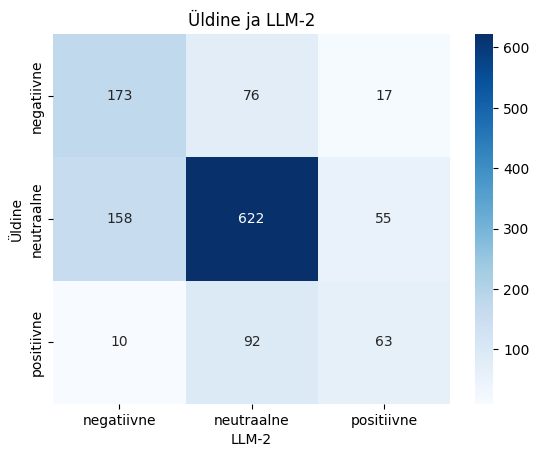

In [36]:
## Üldsie ja LLM rohkem konteksti heatmap sest need on täpsemad mõlemast
overall_vs_llm3 = pd.crosstab(results["overall_label"], results["llm_label_third"])

labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine

#fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(overall_vs_llm3, annot=True, fmt="d",
    cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.title("Üldine ja LLM-2")
plt.xlabel("LLM-2")
plt.ylabel("Üldine")


plt.show();


In [21]:
display(overall_vs_llm3)

NameError: name 'overall_vs_llm3' is not defined

In [22]:
pd.set_option('display.max_colwidth', None)

## Erinevuste näited

In [23]:
overall_topic_differneces = results[results["overall_label"] != results["topic_label_3class"]].copy()
print("Erinevusi kokku:", overall_topic_differneces.shape[0])

label_order = ["negative", "neutral", "positive"]

samples = []

for overall in label_order:
    for topic in label_order:
        # skip kui sama label (ei ole "difference")
        if overall == topic:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["topic_label_3class"] == topic)
        ]
        
        if len(subset) > 0:
            sample = subset.sample(1, random_state=42)
            samples.append(sample)

# liidame kõik kokku
pair_samples_1 = pd.concat(samples)

display(pair_samples_1[[
    "clean_post_text",
    "overall_label",
    "topic_label_3class"
]])

Erinevusi kokku: 329


,clean_post_text,overall_label,topic_label_3class
484,"whats hubspot bad at Hi, thinking about using hubspot, is there anything its not great at? Can automate some things outside of hubspot if its weak in some areas. Thanks!",negative,neutral
1117,"It’s time to actually use HubSpot’s lead capture tools I can’t tell you how many HubSpot portals I’ve opened where the lead capture tools are just sitting there. Forms not connected. Pop-ups disabled. Tracking code missing. And then people wonder why nothing new is coming into their CRM. I mean, you don’t need a huge strategy to start generating leads, you just need to use the basics that are already built in. Here’s where I’d start: * Install the tracking code on every page! * Add a simple form to your highest-traffic page (even a “Request pricing” or “Contact us” form) * Test out the meeting widget * Try one pop-up or slide-in with a clear helpful offer * Track what’s actually converting, not just what’s getting clicks. These are very easy tools to set up and use but they can make a huge difference. You’d be surprised how much growth comes from simply turning on what you already have. As someone who used to work at HubSpot and now helps clients set up and optimise their portals at [Baskey Digital]( I still find that the simplest setups often perform best. Any other HubSpot features you’ve seen make the biggest impact when a team finally started using it?",negative,positive
1106,"HubSpot API 404 on new Bach List Membership endpoint Hi all, Recently HubSpot announced a new batch endpoint for checking association list memberships by POST'ing to /crm/v3/lists/records/memberships/batch/read However, for some reason, I keep 404'ing to that endpoint. Does anyone else have this issue? Did anyone find a fix? Find the announcement [here]( 3rd heading. Find the API docs relevant to the new batch endpoint [here]( I'm experienced in building API-heavy workflows, and I am very confident my setup is correct. See attached screenshots for reference. I contacted Support, they replied quickly and said: ""Based on the error details, in fact it just looks like the endpoint is not available yet in your workspace. This usually happens when the endpoint is newly released but not fully rolled out to all portals."" In my experience, if they do a staged rollout they'd mention it clearly in communications and the error would not be a 404 but a 401 or 403. To me it seems like this endpoint should be available. Anyone experiencing a similar issue?",neutral,negative
891,Upgraded to Enterprise (Marketing and Content Hub) - what should be my first move? Upgraded from Pro to Enterprise (or whatever the level below enterprise is called). What are the obvious things I now have access to that I should take advantage of?,neutral,positive
975,"Database Damage on a Regular Basis I love AI, it's a tool that has improved my life in many ways when it comes to efficiency and workflow. I have never had so many disappointments though since I started with HubSpot around July or August. I am so tired of the unacceptable untrained AI changing phone numbers and deleting contacts that I actually work with. Rant over. I'm ready to ditch it.",positive,negative
659,"A question about HubSpot campaigns and UTM tracking Hi everyone, I hope you're having wonderful weeks. We're just starting to use campaigns in our HubSpot and I had a question. Say we have a campaign called ""ntc"" and I set the utm\_campaign parameter in the campaign manager to ""ntc"", do I then need to create the URLs inside the campaign manager, or can I carry on using a UTM spreadsheet, so long as I include the utm\_campaign as ""ntc"". Ideally, we'd like all of our PPC, email and outreach to have this UTM in for tracking.",positive,neutral


In [41]:
results[(results["llm_label_second"] == "negative") & (results["llm_label_third"] == "positive")]

,id,subreddit_name,source_set,score,created_utc,clean_post_text,overall_label,overall_negative,overall_neutral,overall_positive,...,topic_negative_or_neutral,topic_positive,topic_strongly_positive,llm_label_second,llm_conf_second,llm_reason_second,llm_label_third,llm_conf_third,llm_reason_third,topic_label_3class


In [27]:
llm_2_3_differences = results[results["llm_label_second"] != results["llm_label_third"]].copy()
print("Erinevusi kokku:", llm_2_3_differences.shape[0])

samples = []

for overall in label_order:
    for llm in label_order:
        if overall == llm:
            continue
        
        subset = results[
            (results["llm_label_second"] == overall) &
            (results["llm_label_third"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_2 = pd.concat(samples)

display(pair_samples_2[[
    "clean_post_text",
    "llm_label_second",
    "llm_reason_second",
    "llm_label_third",
    "llm_reason_third"
]])

Erinevusi kokku: 302


,clean_post_text,llm_label_second,llm_reason_second,llm_label_third,llm_reason_third
2,"Marketing ,Sales alignment is killing me. Anyone actually solved this? Every quarter it's the same fight. Marketing says we delivered X leads. Sales says leads are garbage. We're using HubSpot for marketing automation and Salesforce for CRM but there's this black hole between 'MQL' and 'closed won' where nobody knows what happened. Attribution is a mess. Sales blames marketing, marketing blames sales. How have you actually solved this beyond just 'communicate better'?",negative,The post highlights frustrations with marketing and sales alignment issues and specifically mentions HubSpot as part of the tech stack involved in a problematic lead attribution process.,neutral,The post expresses frustration about marketing and sales alignment issues and mentions using HubSpot but does not directly criticize or praise HubSpot itself; it mainly seeks advice.
649,"Built a small app to convert CSV contact list exported from Hubspot to LinkedIn audience format I recently decided to test LinkedIn Ads. Pretty quickly, I realized you can’t take a CSV exported from HubSpot and import it directly into LinkedIn. The formats just don’t match, and LinkedIn doesn’t even provide an interface to map columns, which felt very weird to me. I also didn’t want to use the native LinkedIn integration, since the contact list was far larger than my marketing contact tier in HubSpot. I searched internet for a solution but couldn’t find anything that solved the problem cleanly. So I built a small app to handle it and I’m sharing it here in case someone runs into the same issue: [uibakery.io/templates/hubspot-to-linkedin-csv-converter]( Everything runs entirely in your browser. No files are uploaded and no data is sent to any server, so your customer data stays safe. Hope it would help anyone.",neutral,The post describes a technical limitation with HubSpot's exported CSV format but overall provides a constructive solution without expressing strong positive or negative emotions towards HubSpot.,negative,"The author expresses frustration that HubSpot's CSV export format does not match LinkedIn's import requirements and that LinkedIn lacks a mapping interface, which led them to build a separate app."
1001,"Phone for HubSpot that actually syncs properly? **Edit:** Quick update in case anyone else is in the same boat. We ended up trying out [**Aircall**]( after a few folks recommended it, and it’s been a massive improvement over what we were doing before. The HubSpot sync is actually reliable (finally), and calls are logging on their own with notes + recordings without me having to double-enter everything. We've been using HubSpot for about 8 months now and overall it's been great for managing our pipeline. However, our current phone setup is killing productivity. Currently using a system where calls don't log automatically so I'm manually entering everything after each call. Looking for a phone for HubSpot that integrates well: click-to-dial from contacts, automatic call logging with recordings, and customer info popping up during calls. We're 6 people now, growing to 10 soon. Right now we just use cell phones and type everything into HubSpot manually. Tried the built-in calling but quality was rough and kept dropping. Few questions for anyone who's solved this: * Does your system show HubSpot contact info during calls or do you switch tabs? * How's call quality for remote workers? (half our team is remote) * Can it auto-create tickets from calls? * Any integration issues or does it stay stable? Any leads would be appreciated.",neutral,"The post acknowledges HubSpot's strengths in pipeline management but highlights significant challenges with its phone integration and calling quality, reflecting a balanced view of pros and cons.",positive,"The author states they've been using HubSpot for 8 months and overall it's been great for managing their pipeline, highlighting satisfaction d

In [ ]:
overall_llm_differences = results[results["overall_label"] != results["llm_label_third"]].copy()
print("Erinevusi kokku:", overall_llm_differences.shape[0])


samples = []

for overall in label_order:
    for llm in label_order:
        if overall == llm:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["llm_label_third"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_2 = pd.concat(samples)

display(pair_samples_2[[
    "clean_post_text",
    "overall_label",
    "llm_label_third"
]])

Erinevusi kokku: 408


clean_post_text  \
110                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Too many tools too many mistakes Right now our sales workflow looks like this: HubSpot for capturing leads Google Sheets for tracking activities, Slack for updates, Ema

: 

: 